## Initial imports and load active learning job from disk

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import scm.plams as plams

from scm.active_learning import ActiveLearningLoop, SimpleActiveLearningJourney
from scm.active_learning.engines import ParAMSEngine
from scm.active_learning.tutorials import find_final_state

In [2]:
# Set this to a specific al_final_state file to make the tutorial fully reproducible.
state_path: Path | None = None
path = find_final_state(state_path)
loop = ActiveLearningLoop.load_model(path)
final_engine = loop.result.final_engine

assert isinstance(final_engine, ParAMSEngine), "This tutorial requires ParAMSEngine"
assert isinstance(loop.journey, SimpleActiveLearningJourney), "This tutorial requires SimpleActiveLearningJourney"

## Structure for production job

We could initialize a PLAMS molecule in many different ways. Here, we get the final frame from the final production simulation in the SAL job, and preoptimize it with UFF.

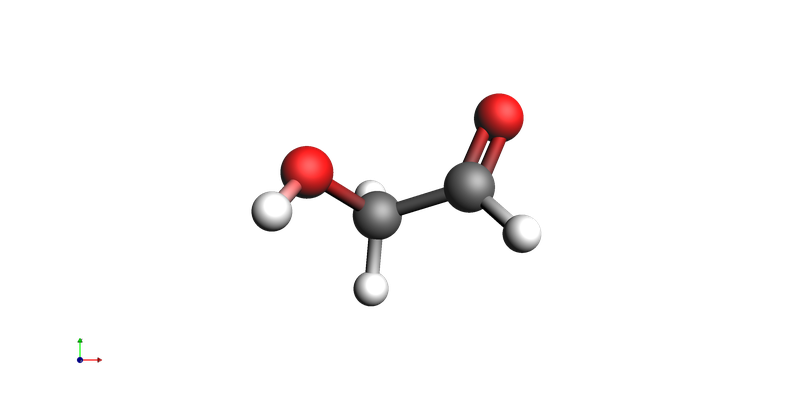

In [3]:
molecule = loop.journey.task.atomistic_system.collect_molecules()[""]
plams.view(molecule)

## Settings for production job

Let's run a geometry optimization + frequencies. But you could run any AMS job!

The ``MaxRestarts`` option is useful when calculating normal modes. If the geometry optimizer converges to a transition state, it will continue until it finds a local minimum!

In [4]:
s = plams.Settings()
s.input.ams.Task = "GeometryOptimization"
s.input.ams.Properties.NormalModes = "Yes"
s.input.ams.GeometryOptimization.MaxRestarts = 5
s.runscript.nproc = 1

new_job = plams.AMSJob(settings=s + final_engine.settings, name="retrained_m3gnet", molecule=molecule)
print(new_job.get_input())

GeometryOptimization
  MaxRestarts 5
End

Properties
  NormalModes Yes
End

Task GeometryOptimization

System
   Atoms
      O 1.4991536204 1.2731398548 -0.3173592522
      C 1.0167936285 0.2263240072 0.1089153272
      C -0.3315553724 -0.1938756412 -0.3224537985
      O -1.3015879788 0.4293877267 0.4399090034
      H 1.6958902087 -0.4272436771 0.6477496177
      H -0.4753659506 0.1030804265 -1.3910249959
      H -0.4273371056 -1.2993890242 -0.3287248652
      H -1.6759910503 -0.1114236726 1.1629889634
   End
   BondOrders
      1 2 2
      2 3 1
      2 5 1
      3 4 1
      3 6 1
      3 7 1
      4 8 1
   End
End

Engine MLPotential
  Backend M3GNet
  MLDistanceUnit angstrom
  MLEnergyUnit eV
  Model Custom
  ParameterDir /home/bene/Documents/work/ALIR/Code/active_learning_workspace/active_learning/tutorials/notebooks/ALruns/20260421_152749/iter_16/ParAMSTrainer/results/optimization/m3gnet/m3gnet
EndEngine




In [5]:
new_job.run();

[21.04|15:56:06] JOB retrained_m3gnet STARTED
[21.04|15:56:06] JOB retrained_m3gnet RUNNING
[21.04|15:56:14] JOB retrained_m3gnet FINISHED
[21.04|15:56:14] JOB retrained_m3gnet SUCCESSFUL


### Optimized structure

<Axes: >

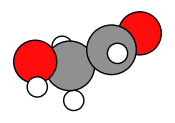

In [6]:
plams.plot_molecule(new_job.results.get_main_molecule())

### Frequencies

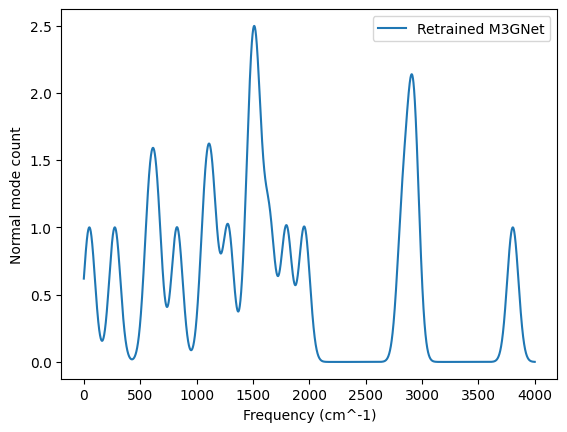

In [7]:
width = 50  # cm^-1
x, y = new_job.results.get_ir_spectrum(broadening_width=width, post_process="all_intensities_to_1")
plt.plot(x, y, label="Retrained M3GNet")
plt.xlabel("Frequency (cm^-1)")
plt.ylabel("Normal mode count")
plt.legend();

## Compare to reference UFF
In this case, we can also calculate the normal modes with the reference method (UFF) and compare:

In [8]:
ref_engine_settings = plams.Settings()
ref_engine_settings.input.ForceField.Type = "UFF"
ref_job = plams.AMSJob(settings=s + ref_engine_settings, name="uff_ref", molecule=molecule)
ref_job.run();

[21.04|15:56:14] JOB uff_ref STARTED
[21.04|15:56:14] JOB uff_ref RUNNING
[21.04|15:56:14] JOB uff_ref FINISHED
[21.04|15:56:14] JOB uff_ref SUCCESSFUL


In [9]:
retrained_structure_rmsd = plams.Molecule.rmsd(
    ref_job.results.get_main_molecule(),
    new_job.results.get_main_molecule(),
    ignore_hydrogen=True,
)
print(f"Structural RMSD: {retrained_structure_rmsd:.2f} angstrom")

Structural RMSD: 0.38 angstrom


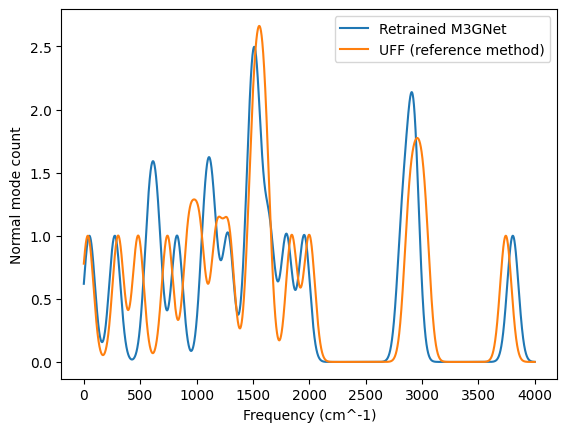

In [10]:
x_ref, y_ref = ref_job.results.get_ir_spectrum(broadening_width=width, post_process="all_intensities_to_1")
plt.plot(x, y, label="Retrained M3GNet")
plt.plot(x_ref, y_ref, label="UFF (reference method)")
plt.xlabel("Frequency (cm^-1)")
plt.ylabel("Normal mode count")
plt.legend();

The agreement looks good! The agreement could have been improved by

* having more training data, for example by setting a tighter success criterion for the forces and energy in the active learning
* running the active learning MD at a lower temperature (closer to the equilibrium structure, but this would mean less conformational sampling)
* training for more epochs

Tip: check if the vibrational frequencies with retrained M3GNet or M3GNet-UP-2022 agree better or worse with the reference UFF calculation.

In [11]:
plams.config.erase_workdir = True
plams.finish()

PLAMS run finished. Goodbye


## Next Step

Take a look at the results and inspect the simulation:

- __[sal-4-continue_with_new_system.ipynb](sal-4-continue_with_new_system.ipynb)__